In [1]:
from generate_scenarios import *
from TSI_analysis import *

import scipy.io as scio

import networkx as nx
import matplotlib.pyplot as plt

In [2]:
PowerGridModel = "IEEE-9"
if PowerGridModel == "IEEE-9":
    raw = "data/ieee9_v33.raw"
    dyr = "data/ieee9bus_gov.dyr"
    n_bus = 9
elif PowerGridModel == "IEEE-39":
    raw = "data/IEEE39_v33.raw"
    dyr = "data/IEEE39_gov.dyr"
    n_bus = 39
else:
    raise RuntimeError(f"{PowerGridModel} is an invalid model!")

number_of_samples = 10
fault_locations   = list(range(1, n_bus + 1))
fault_impedances  = [0.0001]

scenarios = sample_scenarios(
    number_of_samples, fault_locations, fault_impedances)
metadata  = generate_metadata(scenarios)

In [3]:
# noise settings
noise_type = "normal"   # "normal", "uniform", "none", 
noise_var  = 0.10       # variance of the chosen distribution TODO: need to change this to be more flexible

simulation_log = run_simulation_driver_batched(
                        raw, dyr, metadata,
                        noise_type=noise_type, noise_var=noise_var,
                        n_jobs=1, batch_size=30)

Processing batch 1 / 3


/usr/WS2/hiop/dane/project/scidac_2025/irabiel/WF_ACOPF/.venv/lib/python3.10/site-packages/uqgrid/io/parse.py:68: UserWarning: Transformer Magnetizing Impedance not Implemented
  warnings.warn("Transformer Magnetizing Impedance not Implemented")


Processing batch 2 / 3
Processing batch 3 / 3


In [4]:
simulation_log = load_simulation_log('./simulation_log.json')
print(len(simulation_log))
# print(simulation_log)

90


⟳ Loading generator delta data...
⟳ loading δ for GenGENROU device 3 on bus 0
⟳ loading δ for GenGENROU device 4 on bus 1
⟳ loading δ for GenGENROU device 5 on bus 2
Found 80 common scenarios
⟳ Processing scenarios...
   Processing scenario 1/80
TSI for all scenarios: (80,)
TSI for all time scenarios: (80, 1203)


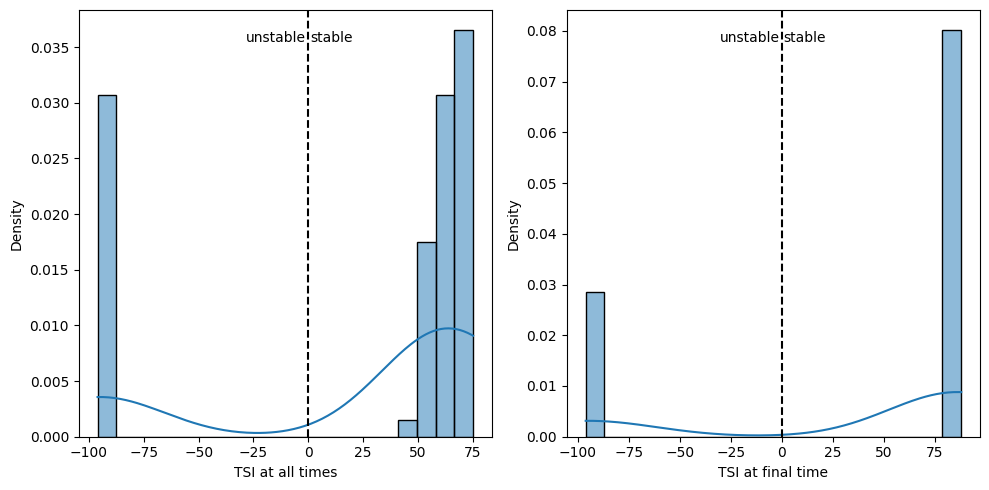

In [5]:
post_data = ComputeTSI()

In [10]:
from collections import defaultdict

# Create dict mapping sample_idx -> list of keys
fault_location_map = defaultdict(list)
for k, v in simulation_log.items():
    fault_location_map[v["fault_location"]].append(k)

# Convert back to normal dict if desired
fault_location_map = dict(fault_location_map)

# build a mapping from uuid -> index
uuid_to_idx = {uuid: i for i, uuid in enumerate(post_data["pl_per_scenario"])}

# Create dicturnary for the fault location and missing faults
fault_location_with_indices = {}
removed_uuids = {}  # store the missing ones here

for floc, uuids in fault_location_map.items():
    valid_uuids = []
    indices = []
    missing = []

    for uid in uuids:
        if uid in uuid_to_idx:
            valid_uuids.append(uid)
            indices.append(uuid_to_idx[uid])
        else:
            missing.append(uid)

    fault_location_with_indices[floc] = {
        "uuids": valid_uuids,
        "indices": indices,
    }

    if missing:  # only add if there are missing keys
        removed_uuids[floc] = missing


print(f"Data is missing at fault location/s {list(removed_uuids.keys())}")

Data is missing at fault location/s [9]


# Plot the graph

In [40]:
# Hardcoded from the ieee9_v33.raw file

fbus = np.array([4,4,5,6,7,8,1,2,9])
tbus = np.array([5,6,7,9,8,9,4,7,3])

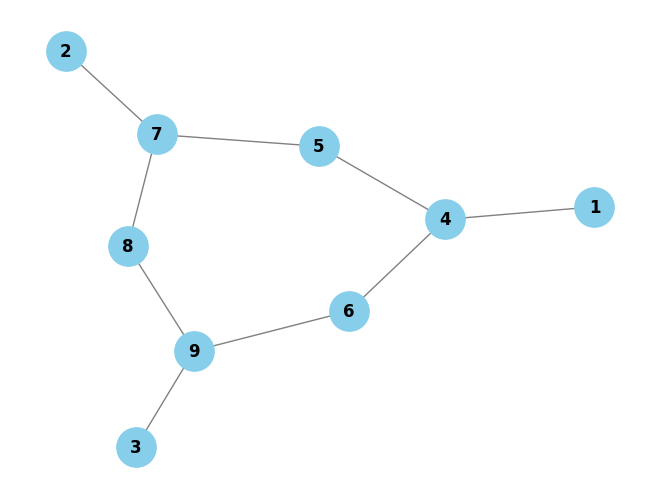

In [43]:
# Create graph
G = nx.Graph()
edges = list(zip(fbus, tbus))
G.add_edges_from(edges)

# Draw graph
pos = nx.spring_layout(G, seed=42)  # layout for nice visualization
nx.draw(G, pos, with_labels=True, node_color="skyblue", node_size=800, font_size=12, font_weight="bold", edge_color="gray")

plt.show()